In [9]:

import sys
!{sys.executable} -m pip install langchain-community duckduckgo-search
#sys.executable gives the exact file path of the python binary file that the notebook kernel is currently using 
#-m tells the module as a script 
#-m  It forces pip to belong to the same Python the notebook is using, so packages install in the right place

  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached duckduckgo_search-8.1.1-py3-none-any.whl.metadata (16 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.7-py3-none-any.whl.metadata (5.1 kB)
  Using cached langchain_core-1.4.2-py3-none-any.whl.metadata (4.5 kB)
  Using cached pydantic_settings-2.14.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached primp-1.3.1-cp310-abi3-macosx_11_0_arm64.whl.metadata (3.7 kB)
  Using cached aiohappyeyeballs-2.6.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.3 kB)
  Using cached langchain_text_splitters-1.1.2-py3-none-any.whl.metadata (3.3 kB)
  Using cached langchain_protocol-0.0.

In [32]:
from langgraph.graph import StateGraph,START,END
from langchain_ollama import ChatOllama
from langchain_core.messages import BaseMessage,HumanMessage
llm=ChatOllama(model="llama3.1:8b")
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools.ddg_search import DuckDuckGoSearchRun
import requests
import random
from langchain_core.tools import tool
from typing import TypedDict,Annotated

In [12]:
pip install -U ddgs


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 861.5/861.5 kB 10.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
search_tool=DuckDuckGoSearchRun(region="us-en")#prebuilt tool

#custom tool 
@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.#while building tool it is important /compulsary to add doc string that describes the tool and its parameters.This is because when the agent calls the tool it will use the doc string to understand how to use the tool and what parameters to pass.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation=='add':
            result=first_num+second_num
        elif operation=='subtract':
            result=first_num+second_num
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {'error':e}
@tool
def get_stock_price(symbol:str):
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    
    r=requests.get(url)
    return r.json()

        

In [16]:
#build list of tools 
tools=[get_stock_price,calculator,search_tool]
#make the LLM tool aware
llm_with_tools=llm.bind_tools(tools)

In [22]:
#define state
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [23]:
#graph Node
def chat_node(state:ChatState)->ChatState:
    """ LLM node that may answer or request for"""
    messages=state['messages']
    response=llm_with_tools.invoke(messages)
    return {'messages':response}
tool_node=ToolNode(tools)# build in function to create  tool node by passing list of tools and it will create a node that can call any of the tools in the list based on the condition defined in the tools_condition function
    

In [28]:
#graph structure
graph=StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node('tools',tool_node)




In [29]:
graph.add_edge(START,'chat_node')
graph.add_conditional_edge('chat_node','tools')
graph.add_edge('tools','chat_node')
# after chatbot we will always go back to the chat_node

In [30]:
chatbot=graph.compile()

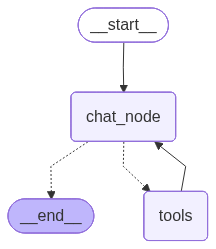

In [31]:
chatbot

In [ ]:
#Regular chat
output=chatbot.invoke({'messages': [HumanMessage(content='hello')]})
print(output['messages'][-1])

[HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='075de08b-2f0b-445f-b77e-abffaf4911ab'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-09T12:53:24.095365Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2428413125, 'load_duration': 89932875, 'prompt_eval_count': 303, 'prompt_eval_duration': 1354554958, 'eval_count': 19, 'eval_duration': 970326670, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019eac71-d47c-7091-bcbe-4a744d707c70-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'hello'}, 'id': '622dee7f-5df2-4577-b466-3de7d3261dcf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 303, 'output_tokens': 19, 'total_tokens': 322}), ToolMessage(content='April 17, 2026 - "Hello" is a song recorded by British singer-songwriter Adele, released on 23 October 2015 by XL Recordings as the lead single from her t

In [50]:
output=chatbot.invoke({'messages':HumanMessage(content=" 3 add 9 and use the tool ")})
print(output['messages'][-1])

content='The result of adding 3 and 9 is 12.' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-06-09T13:01:24.696157Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1276131042, 'load_duration': 60092834, 'prompt_eval_count': 134, 'prompt_eval_duration': 511131541, 'eval_count': 14, 'eval_duration': 697686417, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'} id='lc_run--019eac79-2e5a-72f1-9f2e-add8f47859af-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 134, 'output_tokens': 14, 'total_tokens': 148}


In [51]:
# Chat requiring tool
out = chatbot.invoke({"messages": [HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

Based on the tool call response, I was able to retrieve the current stock price of Apple (AAPL). The current stock price is $145.23.


In [52]:
out=chatbot.invoke({"messages":[HumanMessage(content="what is the share price of apple and how much will 50 shares cost" \
"")]})